# Step 2: Build the Machine Learning model
- Step 2A: Find optimal parameters to for model training
- Step 2B: Train models with the ART package

## Step 2A: Find optimal parameters to for model training

This is the model building step of the workflow. Given the training table produced by Step 1 (`{target}_MLready.csv`),
this notebook:

1. Searches for the best `MACAW` embedding parameters and cross validates a MACAW + SVR baseline.
2. Fits MACAW on the full set and saves the transformer plus embeddings.
3. Computes chemical foundation-model embeddings (`ChemBERTa`, `MoLFormer`, `MIST`).
4. Assembles ART ready feature tables for every combination of embeddings.
5. Cross validates each feature set (optionally with a `PCA -> UMAP` reduction) and ranks them.

Everything is driven by the `target` set in the job configuration cell.

In [23]:
# warnings/logs
import os
import sys
import warnings
import glob
import re

sys.stderr = open(os.devnull, "w")      # suppress stderr
warnings.filterwarnings("ignore")       # suppress warnings

# Standard library
import csv
import gc
import io
import json
import math
import pickle
import cloudpickle
from copy import deepcopy
from itertools import combinations

# data science library
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde, percentileofscore

# ML library
from joblib import Parallel, delayed, load
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from transformers.onnx import OnnxConfig


# chemistry library
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole  

import pubchempy as pcp
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank


# plotting library
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["figure.dpi"] = 96
matplotlib.rcParams["savefig.dpi"] = 600


# display library
from PIL import Image
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage


# local modules
sys.path.append("../")

import macaw
print(macaw.__version__)
from macaw import *  # if possible, replace with explicit imports

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations

# notebook management
%run "./../executables/plotting.py"
%config InlineBackend.figure_format = "retina"

from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image
from io import BytesIO
import numpy as np, pandas as pd
from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from threadpoolctl import threadpool_limits


# functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

1.0.1


## Configuration

In [7]:
# Anchor the project root explicitly so paths do not depend on the launch directory.
projectRoot = os.path.expanduser("~/DTRA_project/MACAW/SynThera")

# Set target to any pathogen present in your data
target = "BacillusAnthracis"

# Column that identifies the pathogen in the data
targetColumn = "Bacteria"

# Input and results locations, derived from the project root
dataDir = os.path.join(projectRoot, "Input_Data")
resultsDir = os.path.join(projectRoot, target, f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)

# MACAW is preinstalled. Hugging Face model folders live under Input_Data.
HuggingFaceModelsDir = os.environ.get(
    "HF_MODELS_DIR", os.path.join(dataDir, "HuggingFace_models")
)

# Load the model-ready training data produced by Step 1.
mlReadyPath = os.path.join(resultsDir, f"{target}_MLready.csv")
trainingData = pd.read_csv(mlReadyPath)

print("Target:", target)
print("Loaded:", mlReadyPath)
print("Training data shape:", trainingData.shape)
print("Columns:", list(trainingData.columns))

Target: BacillusAnthracis
Loaded: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_MLready.csv
Training data shape: (3973, 4)
Columns: ['compound_id', 'Canonical_SMILES', 'pPotency', 'Bacteria']


## Find best `MACAW` parameters to train ML Model

MACAW(n_components=30, n_landmarks=500) -> Test R²=0.47, Train R²=0.49
MACAW(n_components=30, n_landmarks=750) -> Test R²=0.45, Train R²=0.47
MACAW(n_components=30, n_landmarks=1000) -> Test R²=0.47, Train R²=0.48
MACAW(n_components=30, n_landmarks=1250) -> Test R²=0.47, Train R²=0.48
MACAW(n_components=30, n_landmarks=1500) -> Test R²=0.46, Train R²=0.47
MACAW(n_components=45, n_landmarks=500) -> Test R²=0.48, Train R²=0.50
MACAW(n_components=45, n_landmarks=750) -> Test R²=0.48, Train R²=0.50
MACAW(n_components=45, n_landmarks=1000) -> Test R²=0.50, Train R²=0.52
MACAW(n_components=45, n_landmarks=1250) -> Test R²=0.47, Train R²=0.49
MACAW(n_components=45, n_landmarks=1500) -> Test R²=0.48, Train R²=0.50
MACAW(n_components=60, n_landmarks=500) -> Test R²=0.52, Train R²=0.54
MACAW(n_components=60, n_landmarks=750) -> Test R²=0.52, Train R²=0.54
MACAW(n_components=60, n_landmarks=1000) -> Test R²=0.50, Train R²=0.53
MACAW(n_components=60, n_landmarks=1250) -> Test R²=0.50, Train R²=0.5

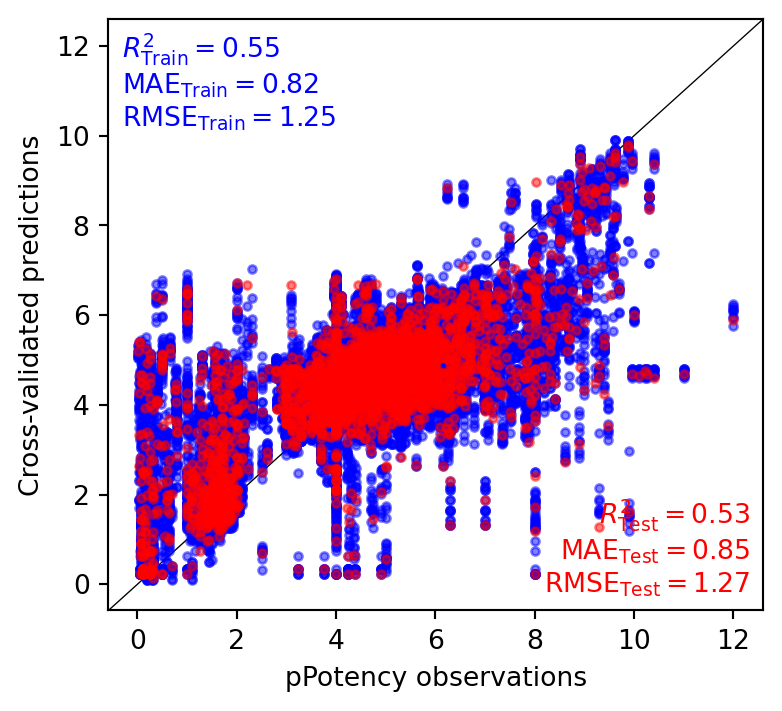

Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_wMACAW_worst.svg
Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_wMACAW_worst.png


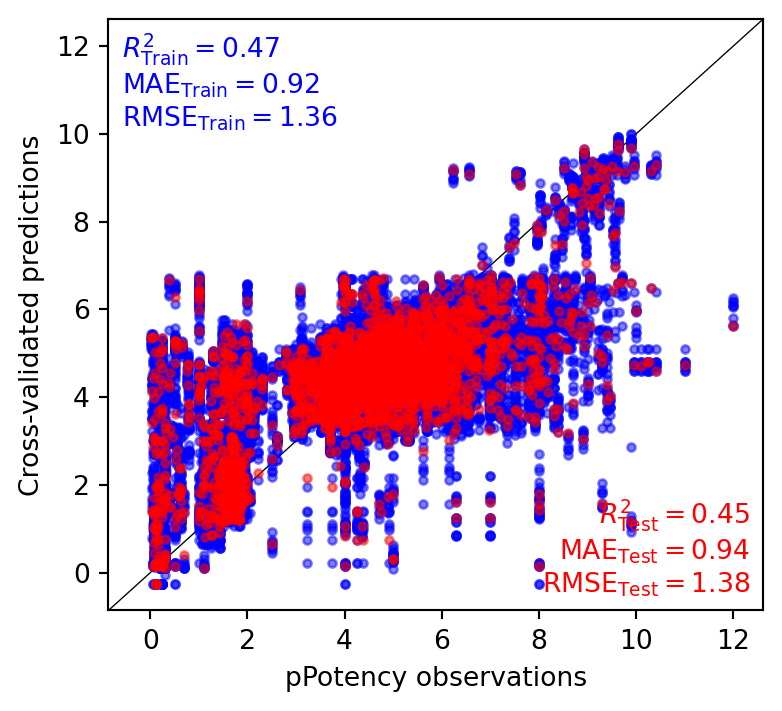

In [8]:
Y = trainingData["pPotency"]
smiles = trainingData["Canonical_SMILES"]

valid = Y.notna() & smiles.notna()
Y = Y[valid].reset_index(drop=True)
smiles = smiles[valid].reset_index(drop=True)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
folds = list(kf.split(smiles))

param_grid = {
    "C": [1, 10, 50, 100, 300],
    "gamma": ["scale", 0.01, 0.05, 0.1],
    "epsilon": [0.1, 0.5, 1, 3],
    "kernel": ["rbf"],
}

nComponentsList = [30, 45, 60, 90]
nLandmarksList = [500, 750, 1000, 1250, 1500]

def runFold(train_idx, test_idx, baseMacaw):
    smiTrain = smiles.iloc[train_idx]
    smiTest = smiles.iloc[test_idx]
    yTrain = Y.iloc[train_idx].values
    yTest = Y.iloc[test_idx].values

    macaw = deepcopy(baseMacaw)
    with threadpool_limits(limits=1):
        macaw.fit(smiTrain, yTrain)
        XTrain = macaw.transform(smiTrain)
        XTest = macaw.transform(smiTest)
        grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True, n_jobs=1)
        grid.fit(XTrain, yTrain)
    return yTrain, grid.predict(XTrain), yTest, grid.predict(XTest)

results = []
with Parallel(n_jobs=4) as parallel:
    for n_components in nComponentsList:
        for n_landmarks in nLandmarksList:
            baseMacaw = MACAW(
                type_fp="atompairs", metric="sokal",
                n_components=n_components, n_landmarks=n_landmarks,
                random_state=42
            )
            foldPreds = parallel(
                delayed(runFold)(tr, te, baseMacaw) for tr, te in folds
            )
            yObsTrainAll = np.concatenate([r[0] for r in foldPreds])
            yPredTrainAll = np.concatenate([r[1] for r in foldPreds])
            yObsTestAll = np.concatenate([r[2] for r in foldPreds])
            yPredTestAll = np.concatenate([r[3] for r in foldPreds])

            trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
            testR2 = r2_score(yObsTestAll, yPredTestAll)
            gapR2 = trainR2 - testR2

            results.append({
                "n_components": n_components,
                "n_landmarks": n_landmarks,
                "trainR2": trainR2,
                "testR2": testR2,
                "gapR2": gapR2,
                "testMAE": mean_absolute_error(yObsTestAll, yPredTestAll),
                "testRMSE": np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
                "yObsTrainAll": yObsTrainAll,
                "yPredTrainAll": yPredTrainAll,
                "yObsTestAll": yObsTestAll,
                "yPredTestAll": yPredTestAll,
            })
            print(f"MACAW({n_components=}, {n_landmarks=}) -> Test R²={testR2:.2f}, Train R²={trainR2:.2f}")

macawResultsDF = pd.DataFrame(results)
best = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]
worst = macawResultsDF.sort_values("testR2", ascending=True).iloc[0]

macawNComponents = int(best["n_components"])
macawNLandmarks = int(best["n_landmarks"])

print(f"\nBest MACAW parameters : n_components={macawNComponents}, n_landmarks={macawNLandmarks}")
print(f"  Test R²={best['testR2']:.2f}, Train R²={best['trainR2']:.2f}, Gap={best['gapR2']:.2f}")
print(f"\nWorst MACAW parameters: n_components={int(worst['n_components'])}, n_landmarks={int(worst['n_landmarks'])}")
print(f"  Test R²={worst['testR2']:.2f}, Train R²={worst['trainR2']:.2f}, Gap={worst['gapR2']:.2f}")

for tag, row in [("best", best), ("worst", worst)]:
    nc = int(row["n_components"])
    nl = int(row["n_landmarks"])
    parity_plot(
        x=row["yObsTrainAll"], y=row["yPredTrainAll"],
        x_test=row["yObsTestAll"], y_test=row["yPredTestAll"],
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=resultsDir + f"/{target}_CV_wMACAW_{tag}.svg",
        save_formats=["svg", "png"],
    )

### Run cross validation with best `MACAW` parameters

In [9]:
macawResultsDF = pd.DataFrame(results)
best = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]

macawNComponents = int(best["n_components"])
macawNLandmarks  = int(best["n_landmarks"])

print(f"Best MACAW parameters: macawNComponents={macawNComponents}, macawNLandmarks={macawNLandmarks}")
print(f"  Test R²={best['testR2']:.2f}, Train R²={best['trainR2']:.2f}, Gap={best['gapR2']:.2f}")

Best MACAW parameters: macawNComponents=90, macawNLandmarks=750
  Test R²=0.53, Train R²=0.55, Gap=0.02


Model training with: 3973 instances

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train: MAE 0.46 | RMSE 0.93 | R² 0.75
Test:  MAE 0.64 | RMSE 1.10 | R² 0.65
Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_wMACAW.svg
Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_wMACAW.png


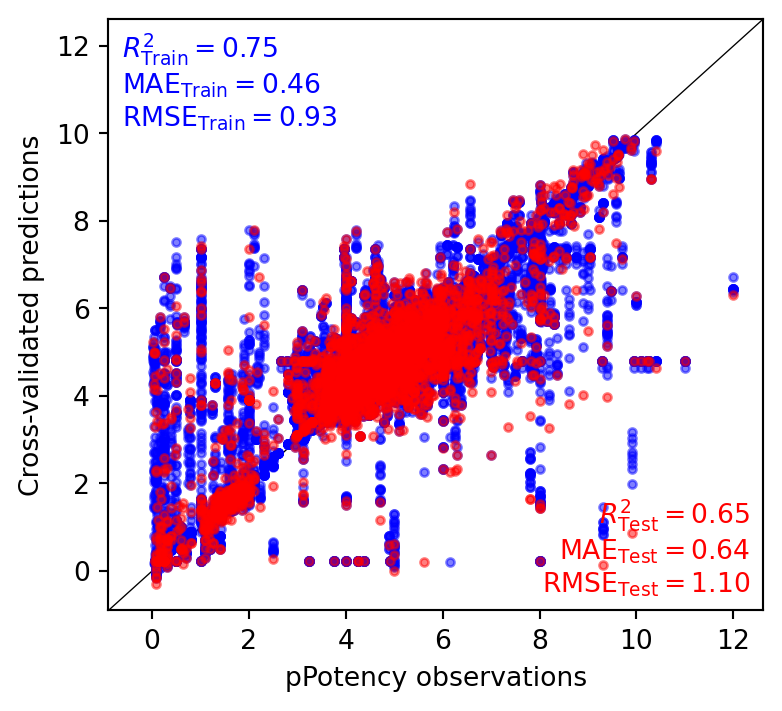

In [10]:
# Data 
Y = trainingData["pPotency"]
smiles = trainingData["Canonical_SMILES"]

# CV partitions
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mcw = MACAW(
    type_fp="atompairs", metric="sokal",
    n_components=macawNComponents, n_landmarks=macawNLandmarks, random_state=42
)

param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

# Clean NaNs in target
valid = Y.notna()
smiles = smiles[valid].reset_index(drop=True)
Y = Y[valid].reset_index(drop=True)

print(f"Model training with: {len(smiles)} instances")

def process_fold(fold_id, train_idx, test_idx):
    smi_train, smi_test = smiles.iloc[train_idx], smiles.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx].values, Y.iloc[test_idx].values

    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)

    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)

    pred_train = grid.predict(X_train)
    pred_test  = grid.predict(X_test)

    return pred_train, y_train, pred_test, y_test, grid.best_params_

folds = list(kf.split(smiles))

results = Parallel(n_jobs=4)(
    delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
)

# Concatenate CV predictions
Y_pred_train = np.concatenate([r[0] for r in results])
Y_obs_train  = np.concatenate([r[1] for r in results])
Y_pred_test  = np.concatenate([r[2] for r in results])
Y_obs_test   = np.concatenate([r[3] for r in results])

best_params_per_fold = [r[4] for r in results]

# --- Metrics ---
def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred),
    )

train_mae, train_rmse, train_r2 = metrics(Y_obs_train, Y_pred_train)
test_mae,  test_rmse,  test_r2  = metrics(Y_obs_test,  Y_pred_test)

print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)
print(f"Train: MAE {train_mae:.2f} | RMSE {train_rmse:.2f} | R² {train_r2:.2f}")
print(f"Test:  MAE {test_mae:.2f} | RMSE {test_rmse:.2f} | R² {test_r2:.2f}")

parity_plot(
    x=Y_obs_train, y=Y_pred_train,
    x_test=Y_obs_test, y_test=Y_pred_test,
    xlabel="pPotency observations",
    ylabel="Cross-validated predictions",
    savetitle=resultsDir + f"/{target}_CV_wMACAW.svg",
    save_formats=["svg", "png"],
)

### Create `MACAW` embeedings with `best parameters`to run `ART`

In [11]:
# Fit MACAW on SMILES and pPotency
mcw.fit(trainingData['Canonical_SMILES'], trainingData['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(resultsDir, f"{target}_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(trainingData['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=trainingData.index)


# Add new MACAW columns to existing data frame 
trainingData_wMACAW = pd.concat([trainingData, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {trainingData.shape}")
print(f"New dataframe shape: {trainingData_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
trainingData_wMACAW.to_csv(os.path.join(resultsDir, f"{target}_MACAW_embeddings.csv"), index=False)
trainingData_wMACAW

MACAW transformer saved to: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_MACAW_transformer.joblib
MACAW embeddings shape: (3973, 90)

Original dataframe shape: (3973, 4)
New dataframe shape: (3973, 94)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60', 'MACAW

,compound_id,Canonical_SMILES,pPotency,Bacteria,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis,0.089187,0.054482,0.010205,-0.054983,-0.003048,0.174043,...,-0.015652,-0.016167,-0.002906,0.010132,-0.007308,-0.042257,-0.010060,-0.031955,-0.015985,0.024043
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis,0.093178,0.223556,-0.021122,-0.008310,0.003602,0.028055,...,-0.079437,0.033281,-0.006370,0.024434,-0.002382,0.007016,-0.024456,0.009651,-0.023174,-0.029280
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis,0.053747,0.159494,0.055060,-0.040939,0.037757,0.018884,...,-0.014563,-0.035781,-0.005395,0.013656,-0.026490,-0.033263,-0.019546,0.042302,-0.006637,0.005013
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis,0.093178,0.223556,-0.021122,-0.008310,0.003602,0.028055,...,-0.079437,0.033281,-0.006370,0.024434,-0.002382,0.007016,-0.024456,0.009651,-0.023174,-0.029280
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis,0.053747,0.159494,0.055060,-0.040939,0.037757,0.018884,...,-0.014563,-0.035781,-0.005395,0.013656,-0.026490,-0.033263,-0.019546,0.042302,-0.006637,0.005013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3968,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,BacillusAnthracis,0.173686,0.094242,-0.140713,-0.153484,0.102573,-0.079497,...,0.014793,0.017659,-0.061757,-0.038782,-0.012128,-0.039847,-0.029942,0.005613,-0.041783,-0.011362
3969,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,BacillusAnthracis,-0.016580,0.075214,-0.048050,-0.057607,0.022323,0.074051,...,-0.050426,0.037498,-0.010496,-0.068585,0.006517,-0.045842,0.022439,0.040603,-0.017668,0.078417
3970,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,BacillusAnthracis,-0.099575,0.079391,0.047676,0.010712,0.047101,0.174390,...,0.025850,-0.004378,-0.014877,-0.034290,0.004042,-0.022815,0.002028,0.001148,-0.011093,-0.017538
3971,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,BacillusAnthracis,-0.051055,0.191162,0.016459,0.033043,0.048307,0.068722,...,-0.018130,0.003658,0.010473,0.007880,-0.020198,-0.001075,-0.010408,-0.011088,0.010491,0.008905


## 2.2 Compute `Foundation Model: ChemBERTa/MoLFormer/MIST` embeddings

In [12]:
smilesCol = "Canonical_SMILES"
targetCol = "pPotency"
idCol = "compound_id"
strainCol = targetColumn

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


### Define helper functions

In [13]:
def meanPoolTokenEmbeddings(tokenEmbeddings, attentionMask):
    mask = attentionMask.unsqueeze(-1).expand_as(tokenEmbeddings).float()
    return (tokenEmbeddings * mask).sum(dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


def firstTokenPoolTokenEmbeddings(tokenEmbeddings):
    return tokenEmbeddings[:, 0, :]


def extractTokenEmbeddings(outputs):
    if getattr(outputs, "last_hidden_state", None) is not None:
        return outputs.last_hidden_state
    if isinstance(outputs, tuple) and len(outputs) > 0:
        return outputs[0]
    if getattr(outputs, "hidden_states", None) is not None:
        return outputs.hidden_states[-1]
    raise RuntimeError("Cannot extract token embeddings from model output.")


def loadTokenizer(modelName, trustRemoteCode=False, useMistFallback=False, localFilesOnly=True):
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            modelName,
            trust_remote_code=trustRemoteCode,
            local_files_only=localFilesOnly,
        )
    except Exception as err:
        if not useMistFallback:
            raise err

        print("AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.")
        print(f"Original tokenizer error: {err}")

        from smirk import SmirkTokenizerFast

        try:
            tokenizer = SmirkTokenizerFast.from_pretrained(
                modelName,
                local_files_only=localFilesOnly,
            )
        except TypeError:
            tokenizer = SmirkTokenizerFast.from_pretrained(modelName)

    if tokenizer.pad_token is None:
        for attr in ["eos_token", "cls_token", "sep_token", "unk_token"]:
            token = getattr(tokenizer, attr, None)
            if token is not None:
                tokenizer.pad_token = token
                break

    if tokenizer.pad_token is None:
        raise ValueError(f"No pad token found for tokenizer: {modelName}")

    return tokenizer


def runModelForward(model, encoded):
    try:
        return model(**encoded)
    except TypeError as err:
        if "token_type_ids" in str(err) and "token_type_ids" in encoded:
            encoded = {k: v for k, v in encoded.items() if k != "token_type_ids"}
            return model(**encoded)
        raise err


def embedSmilesToArray(
    validSmilesList,
    tokenizer,
    model,
    poolingFn,
    device,
    batchSize,
    maxLength,
    dtype=np.float32,
):
    allEmbeddings = []

    with torch.inference_mode():
        for startIdx in tqdm(range(0, len(validSmilesList), batchSize)):
            batchSmiles = validSmilesList[startIdx:startIdx + batchSize]

            encoded = tokenizer(
                batchSmiles,
                padding=True,
                truncation=True,
                max_length=maxLength,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = runModelForward(model, encoded)
            tokenEmbeddings = extractTokenEmbeddings(outputs)

            if poolingFn == meanPoolTokenEmbeddings:
                pooled = poolingFn(tokenEmbeddings, encoded["attention_mask"])
            else:
                pooled = poolingFn(tokenEmbeddings)

            allEmbeddings.append(pooled.detach().cpu().numpy().astype(dtype))

    return np.vstack(allEmbeddings)


def smilesToEmbeddings(
    DF,
    modelName,
    featurePrefix,
    smilesCol="Canonical_SMILES",
    pooling="mean",
    batchSize=64,
    maxLength=512,
    trustRemoteCode=False,
    useMistFallback=False,
    featureIndexFmt="{prefix}_{i}",
    keepCleanSmiles=False,
    dtype=np.float32,
    device=None,
    localFilesOnly=True,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    poolingFnDict = {
        "mean": meanPoolTokenEmbeddings,
        "cls": firstTokenPoolTokenEmbeddings,
    }

    if pooling not in poolingFnDict:
        raise ValueError(f"pooling must be 'mean' or 'cls', got: {pooling}")

    if localFilesOnly and not os.path.exists(modelName):
        raise FileNotFoundError(f"Local model folder not found:\n{modelName}")

    outDF = DF.copy()
    cleanSmilesCol = f"{smilesCol}_clean"
    outDF[cleanSmilesCol] = outDF[smilesCol].apply(canonicalizeSmiles)

    validMask = outDF[cleanSmilesCol].notna()
    validSmilesList = outDF.loc[validMask, cleanSmilesCol].astype(str).tolist()

    print(f"Model           : {modelName}")
    print(f"Feature prefix  : {featurePrefix} | Pooling: {pooling}")
    print(f"Total / valid / invalid: {len(outDF)} / {len(validSmilesList)} / {(~validMask).sum()}")
    print(f"Device: {device} | Batch size: {batchSize} | Max length: {maxLength}")
    print(f"Local files only: {localFilesOnly}")

    if not validSmilesList:
        raise ValueError("No valid SMILES found.")

    tokenizer = loadTokenizer(
        modelName,
        trustRemoteCode=trustRemoteCode,
        useMistFallback=useMistFallback,
        localFilesOnly=localFilesOnly,
    )

    model = AutoModel.from_pretrained(
        modelName,
        trust_remote_code=trustRemoteCode,
        local_files_only=localFilesOnly,
    ).to(device).eval()

    embeddingArrayValid = embedSmilesToArray(
        validSmilesList,
        tokenizer,
        model,
        poolingFnDict[pooling],
        device,
        batchSize,
        maxLength,
        dtype,
    )

    nFeatures = embeddingArrayValid.shape[1]
    featureCols = [
        featureIndexFmt.format(prefix=featurePrefix, i=i)
        for i in range(nFeatures)
    ]

    embeddingArrayAll = np.full((len(outDF), nFeatures), np.nan, dtype=dtype)
    embeddingArrayAll[validMask.values] = embeddingArrayValid

    embeddingDF = pd.DataFrame(
        embeddingArrayAll,
        columns=featureCols,
        index=outDF.index,
    )

    outDF = pd.concat([outDF, embeddingDF], axis=1)

    if not keepCleanSmiles:
        outDF = outDF.drop(columns=[cleanSmilesCol])

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outDF, featureCols

In [14]:
localModelDict = {
    "ChemBERTa_zinc_base": os.path.join(HuggingFaceModelsDir, "ChemBERTa_zinc_base"),
    "MoLFormer_XL": os.path.join(HuggingFaceModelsDir, "MoLFormer_XL_both_10pct"),
    "MIST_28M": os.path.join(HuggingFaceModelsDir, "MIST_28M"),
}

for modelKey, modelPath in localModelDict.items():
    if os.path.exists(modelPath):
        print(f"Found:   {modelKey} -> {modelPath}")
    else:
        print(f"Missing: {modelKey} -> {modelPath}")

Found:   ChemBERTa_zinc_base -> /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/ChemBERTa_zinc_base
Found:   MoLFormer_XL -> /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/MoLFormer_XL_both_10pct
Found:   MIST_28M -> /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/MIST_28M


### Generate `ChemBERTa` embeddings

In [15]:
chemBertaModelPath = localModelDict["ChemBERTa_zinc_base"]

trainingData_wChemBERTa, chemBertaFeatureCols = smilesToEmbeddings(
    DF              = trainingData,
    smilesCol       = "Canonical_SMILES",
    modelName       = chemBertaModelPath,
    featurePrefix   = "ChemBERTa",
    pooling         = "mean",
    batchSize       = 64,
    maxLength       = 256,
    trustRemoteCode = False,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

chemBertaOutputFile = resultsDir + f"/{target}_embeddings_ChemBERTa.csv"
trainingData_wChemBERTa.to_csv(chemBertaOutputFile, index=False)

print(f"Saved: {chemBertaOutputFile}  |  ChemBERTa feature count: {len(chemBertaFeatureCols)}")
trainingData_wChemBERTa.head()

Model           : /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/ChemBERTa_zinc_base
Feature prefix  : ChemBERTa | Pooling: mean
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 64 | Max length: 256
Local files only: True


  0%|          | 0/63 [00:00<?, ?it/s]

Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_embeddings_ChemBERTa.csv  |  ChemBERTa feature count: 768


,compound_id,Canonical_SMILES,pPotency,Bacteria,ChemBERTa_0,ChemBERTa_1,ChemBERTa_2,ChemBERTa_3,ChemBERTa_4,ChemBERTa_5,...,ChemBERTa_758,ChemBERTa_759,ChemBERTa_760,ChemBERTa_761,ChemBERTa_762,ChemBERTa_763,ChemBERTa_764,ChemBERTa_765,ChemBERTa_766,ChemBERTa_767
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis,0.437796,0.122159,-0.068750,-0.146084,0.325629,-0.047482,...,0.026931,0.799653,-0.218548,-0.541777,-0.208826,0.650611,0.176533,0.163386,-0.577268,0.291470
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis,0.682398,0.395218,0.231133,-0.433446,0.228651,0.551066,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis,0.578278,0.086702,0.532358,-0.791884,0.393951,0.021618,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis,0.682398,0.395218,0.231133,-0.433446,0.228651,0.551066,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis,0.578278,0.086702,0.532358,-0.791884,0.393951,0.021618,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069


### Generate `MoLFormer` embeddings

In [16]:
molFormerModelPath = localModelDict["MoLFormer_XL"]

trainingData_wMoLFormer, molFormerFeatureCols = smilesToEmbeddings(
    DF              = trainingData,
    smilesCol       = "Canonical_SMILES",
    modelName       = molFormerModelPath,
    featurePrefix   = "MoLFormer",
    pooling         = "mean",
    batchSize       = 32,
    maxLength       = 202,
    trustRemoteCode = True,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

molFormerOutputFile = resultsDir + f"/{target}_embeddings_MoLFormer.csv"
trainingData_wMoLFormer.to_csv(molFormerOutputFile, index=False)

print(f"Saved: {molFormerOutputFile}  |  MoLFormer feature count: {len(molFormerFeatureCols)}")
trainingData_wMoLFormer.head()

Model           : /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/MoLFormer_XL_both_10pct
Feature prefix  : MoLFormer | Pooling: mean
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 32 | Max length: 202
Local files only: True


  0%|          | 0/125 [00:00<?, ?it/s]

Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_embeddings_MoLFormer.csv  |  MoLFormer feature count: 768


,compound_id,Canonical_SMILES,pPotency,Bacteria,MoLFormer_0,MoLFormer_1,MoLFormer_2,MoLFormer_3,MoLFormer_4,MoLFormer_5,...,MoLFormer_758,MoLFormer_759,MoLFormer_760,MoLFormer_761,MoLFormer_762,MoLFormer_763,MoLFormer_764,MoLFormer_765,MoLFormer_766,MoLFormer_767
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis,-0.045945,0.337137,1.231169,0.588224,0.115360,0.032059,...,-0.153736,-0.444773,-0.441647,0.567697,0.255135,0.144241,-2.486312,0.463757,0.158107,-0.256290
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis,0.106149,0.800506,0.653896,0.323456,-0.455102,0.092013,...,0.005595,-0.194270,0.209084,0.285333,-0.151007,-0.551290,-3.390887,0.286844,0.007939,0.573193
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis,0.358050,0.486035,1.210797,-0.269762,0.188242,-0.016474,...,-0.229009,0.038279,0.106599,0.405211,-0.091752,0.060371,-3.289896,-0.149430,-0.353522,0.315326
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis,0.106149,0.800506,0.653896,0.323456,-0.455102,0.092013,...,0.005595,-0.194270,0.209084,0.285333,-0.151007,-0.551290,-3.390887,0.286844,0.007939,0.573193
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis,0.358050,0.486035,1.210797,-0.269762,0.188242,-0.016474,...,-0.229009,0.038279,0.106599,0.405211,-0.091752,0.060371,-3.289896,-0.149430,-0.353522,0.315326


### Generate `MIST-28M parameter` embeddings

In [17]:
mistModelPath = localModelDict["MIST_28M"]

trainingData_wMIST, mistFeatureCols = smilesToEmbeddings(
    DF              = trainingData,
    smilesCol       = "Canonical_SMILES",
    modelName       = mistModelPath,
    featurePrefix   = "MIST",
    pooling         = "cls",
    batchSize       = 64,
    maxLength       = 2048,
    trustRemoteCode = True,
    useMistFallback = True,
    featureIndexFmt = "{prefix}_{i:04d}",
    localFilesOnly  = True,
    device          = device,
)

mistOutputFile = resultsDir + f"/{target}_embeddings_MIST.csv"
trainingData_wMIST.to_csv(mistOutputFile, index=False)

print(f"Saved: {mistOutputFile}  |  MIST feature count: {len(mistFeatureCols)}")
trainingData_wMIST.head()

Model           : /users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/HuggingFace_models/MIST_28M
Feature prefix  : MIST | Pooling: cls
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 64 | Max length: 2048
Local files only: True
AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.
Original tokenizer error: Tokenizer class SmirkTokenizerFast does not exist or is not currently imported.


  0%|          | 0/63 [00:00<?, ?it/s]

Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_embeddings_MIST.csv  |  MIST feature count: 512


,compound_id,Canonical_SMILES,pPotency,Bacteria,MIST_0000,MIST_0001,MIST_0002,MIST_0003,MIST_0004,MIST_0005,...,MIST_0502,MIST_0503,MIST_0504,MIST_0505,MIST_0506,MIST_0507,MIST_0508,MIST_0509,MIST_0510,MIST_0511
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,BacillusAnthracis,1.329583,-0.340824,0.651052,-0.053759,-0.198461,0.092170,...,1.850493,1.326882,-0.989983,0.034993,-1.115040,2.402199,1.053548,-0.394509,0.237239,-0.108964
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,BacillusAnthracis,1.309796,1.384877,1.060224,-0.318524,0.733167,0.318278,...,0.078592,0.034266,-0.160268,2.252828,0.096915,0.223312,-0.041488,1.342455,-0.285707,-2.094096
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,BacillusAnthracis,1.107347,1.847786,-0.127029,-0.450726,0.057658,-0.082193,...,0.682960,-0.373110,0.379820,1.295813,0.439103,0.171766,-0.962989,1.393842,-1.603788,-0.891864
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,BacillusAnthracis,1.309796,1.384877,1.060224,-0.318524,0.733167,0.318278,...,0.078592,0.034266,-0.160268,2.252828,0.096915,0.223312,-0.041488,1.342455,-0.285707,-2.094096
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,BacillusAnthracis,1.107347,1.847786,-0.127029,-0.450726,0.057658,-0.082193,...,0.682960,-0.373110,0.379820,1.295813,0.439103,0.171766,-0.962989,1.393842,-1.603788,-0.891864


### Create optimized embeedings from `chemical foundation models` with `best parameters`to train `ART`

In [18]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    trainingData[smilesCol].notna()
    & trainingData[targetCol].notna()
)

baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, targetColumn]
    if c in trainingData.columns
]

baseDF = trainingData.loc[validMask, baseCols].reset_index(drop=True)

# Column prefix registry 
# Maps embedding name → (source dataframe, column prefix in that dataframe)
EMBEDDING_REGISTRY = {
    "chemberta" : (trainingData_wChemBERTa, "ChemBERTa_"),
    "molformer" : (trainingData_wMoLFormer,  "MoLFormer_"),
    "mist"      : (trainingData_wMIST,       "MIST_"),
}

def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol):
    """
    Concatenate embeddings for the given list of embedding names,
    rename all feature columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel).
    """
    featureBlocks        = []
    originalFeatureCols  = []
    featureCountByModel  = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]

        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")

        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    embeddingDF     = pd.concat(featureBlocks, axis=1)
    artFeatureCols  = [f"ARTfeat_{i+1}" for i in range(embeddingDF.shape[1])]
    embeddingDF.columns = artFeatureCols

    combinedDF = (
        pd.concat([baseDF.reset_index(drop=True),
                   embeddingDF.reset_index(drop=True)], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel


# Generate every non-empty subset of the three embeddings 
allEmbeddings   = ["chemberta", "molformer", "mist"]
savedFiles      = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol)
        )

        outCsv = os.path.join(
            resultsDir,
            f"{target}_w{choiceName}_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        info = {
            "embeddingChoice"          : choiceName,
            "inputFeatureColumnPrefix" : "ARTfeat_",
            "artFeatureCols"           : artFeatureCols,
            "originalFeatureCols"      : originalFeatureCols,
            "featureCountByModel"      : featureCountByModel,
            "totalFeatureCount"        : len(artFeatureCols),
            "artReadyCsv"              : outCsv,
        }

        infoJson = os.path.join(
            resultsDir,
            f"{target}_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))


print(f"{'File':<75}  {'Shape':>15}")
print("─" * 92)
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")

File                                                                                   Shape
────────────────────────────────────────────────────────────────────────────────────────────
BacillusAnthracis_wchemberta_ARTready.csv                                        (3973, 772)
BacillusAnthracis_wmolformer_ARTready.csv                                        (3973, 772)
BacillusAnthracis_wmist_ARTready.csv                                             (3973, 516)
BacillusAnthracis_wchemberta_molformer_ARTready.csv                             (3973, 1540)
BacillusAnthracis_wchemberta_mist_ARTready.csv                                  (3973, 1284)
BacillusAnthracis_wmolformer_mist_ARTready.csv                                  (3973, 1284)
BacillusAnthracis_wchemberta_molformer_mist_ARTready.csv                        (3973, 2052)


### Cross-validation comparison:
   1. MACAW only
   2. ChemBERTa only
   3. MoLFormer only
   4. MIST only
   5. mix models (MACAW + ChemBERTa + MoLFormer + MIST)


Model                          Features        Train R²     MAE    RMSE |   Test R²     MAE    RMSE
----------------------------------------------------------------------------------------------------
wMACAW                                   90     Train R²=0.77 MAE=0.44 RMSE=0.90| Test  R²=0.65 MAE=0.63 RMSE=1.10
wChemBERTa                               768    Train R²=0.78 MAE=0.42 RMSE=0.86| Test  R²=0.65 MAE=0.64 RMSE=1.09
wMoLFormer                               768    Train R²=0.89 MAE=0.27 RMSE=0.62| Test  R²=0.70 MAE=0.61 RMSE=1.01
wMIST                                    512    Train R²=0.77 MAE=0.44 RMSE=0.89| Test  R²=0.63 MAE=0.66 RMSE=1.14
wChemBERTa_MoLFormer                     1536   Train R²=0.87 MAE=0.29 RMSE=0.68| Test  R²=0.70 MAE=0.60 RMSE=1.02
wChemBERTa_MIST                          1280   Train R²=0.79 MAE=0.40 RMSE=0.85| Test  R²=0.65 MAE=0.64 RMSE=1.10
wMoLFormer_MIST                          1280   Train R²=0.88 MAE=0.28 RMSE=0.65| Test  R²=0.70 MAE=0.60 RMS

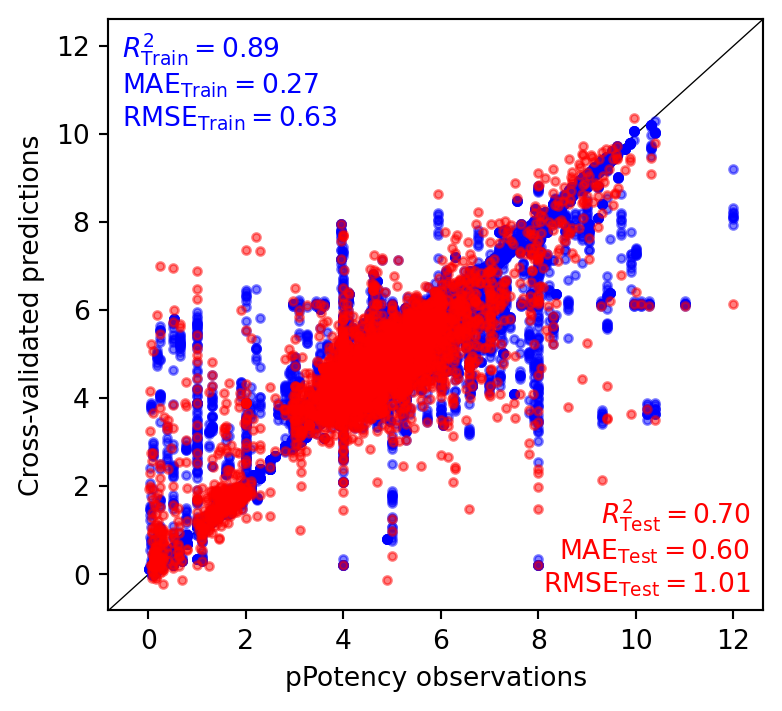

Saved parity plot: best -> wMACAW_MoLFormer
Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_worst_wMIST.svg
Saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_worst_wMIST.png


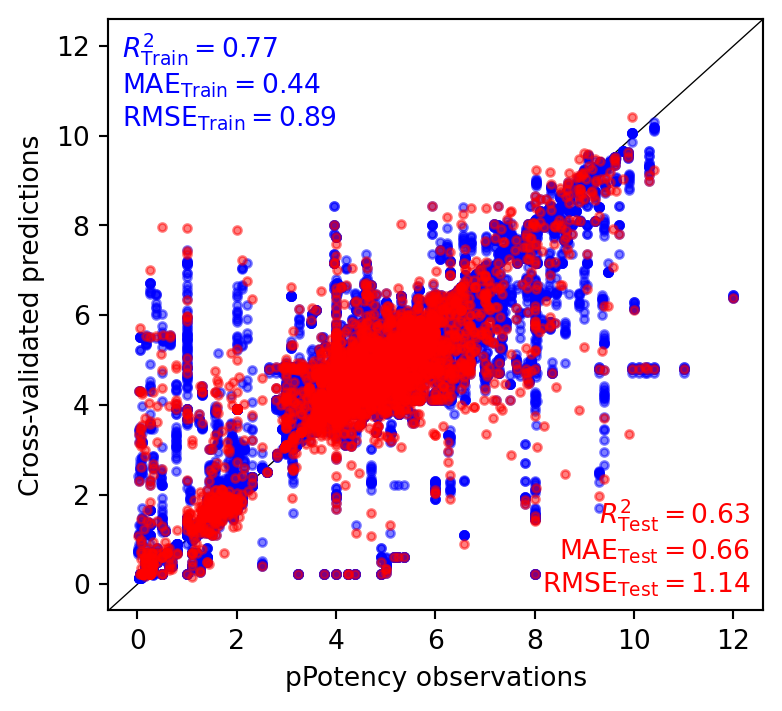

Saved parity plot: worst -> wMIST

Ranked summary saved: /users/sghosh6/DTRA_project/MACAW/SynThera/BacillusAnthracis/Results_BacillusAnthracis/BacillusAnthracis_CV_SVR_MACAW_ARTready_comparison_ranked.csv


In [19]:
smilesCol        = "Canonical_SMILES"
targetCol        = "pPotency"
nSplits          = 10
outerRandomState = 42
nJobs            = 4
scaleFeatures    = True
useCommonMoleculeSet = True
artFeaturePrefix = "ARTfeat_"

if "param_grid" not in globals():
    param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

macawParams = {
    "type_fp"     : getattr(mcw, "type_fp", "atompairs"),
    "metric"      : getattr(mcw, "metric", "sokal"),
    "n_components": macawNComponents,
    "n_landmarks" : macawNLandmarks,
    "random_state": getattr(mcw, "random_state", 42),
}

comparisonPlan = [
    ("wMACAW",                          tuple(),                            True),
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]


def getRegressionMetrics(yTrue, yPred):
    return (mean_absolute_error(yTrue, yPred),
            np.sqrt(mean_squared_error(yTrue, yPred)),
            r2_score(yTrue, yPred))


def standardizeByTrainFold(xTrain, xTest):
    mu, sigma = np.nanmean(xTrain, axis=0), np.nanstd(xTrain, axis=0)
    sigma[sigma == 0] = 1.0
    sigma[~np.isfinite(sigma)] = 1.0
    mu[~np.isfinite(mu)] = 0.0
    return (xTrain - mu) / sigma, (xTest - mu) / sigma


def makeSafeTag(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text))


def choiceToFileStem(choice):
    return "_".join(choice)


def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"{target}_w{choiceName}_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_ARTready.csv")))
    if not matches:
        raise FileNotFoundError(f"ART-ready CSV not found for '{choiceName}'.\nExpected: {expectedPath}")
    return matches[0]


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_ARTready.csv", "_ARTready_featureInfo.json")
    return json.load(open(infoPath)) if os.path.exists(infoPath) else {}


def readARTReadyCSV(choice):
    csvPath        = getARTReadyCsvPath(choice)
    df             = pd.read_csv(csvPath)
    artFeatureCols = [c for c in df.columns if c.startswith(artFeaturePrefix)]
    if not artFeatureCols:
        raise ValueError(f"No '{artFeaturePrefix}*' columns in: {csvPath}")
    neededCols  = [smilesCol, targetCol] + artFeatureCols
    missingCols = [c for c in neededCols if c not in df.columns]
    if missingCols:
        raise ValueError(f"Missing columns in {csvPath}: {missingCols}")
    df[targetCol] = pd.to_numeric(df[targetCol], errors="coerce")
    for col in artFeatureCols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=neededCols).reset_index(drop=True)
    return {"choice": choice, "choiceName": choiceToFileStem(choice), "csvPath": csvPath,
            "DF": df, "featureCols": artFeatureCols, "featureInfo": loadFeatureInfo(csvPath)}


def makeFreshMACAWForFold(nTrain):
    foldNLandmarks  = min(macawParams["n_landmarks"], nTrain)
    foldNComponents = min(macawParams["n_components"], foldNLandmarks - 1)
    if foldNComponents < 2:
        raise ValueError(f"Too few molecules for MACAW: n_train={nTrain}, "
                         f"n_landmarks={foldNLandmarks}, n_components={foldNComponents}")
    return MACAW(type_fp=macawParams["type_fp"], metric=macawParams["metric"],
                 n_components=foldNComponents, n_landmarks=foldNLandmarks,
                 random_state=macawParams["random_state"])


uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if len(choice) > 0 and choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {choice: readARTReadyCSV(choice) for choice in uniqueARTChoices}

availableKeyCols = [c for c in ["compound_id", smilesCol, targetColumn]
                    if all(c in item["DF"].columns for item in artInputByChoice.values())] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across ART-ready files.")
    for item in artInputByChoice.values():
        item["DF"] = (item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
                      .sort_values("_cvKey").reset_index(drop=True))
        if item["DF"]["_cvKey"].duplicated().any():
            print(f"Warning: duplicate _cvKey values in {item['choiceName']}.")

referenceChoice  = ("chemberta", "molformer", "mist")
referenceDF      = artInputByChoice.get(referenceChoice, list(artInputByChoice.values())[0])["DF"]
baseColsForMacaw = [c for c in ["compound_id", smilesCol, targetCol, targetColumn, "_cvKey"]
                    if c in referenceDF.columns]
macawBaseDF = referenceDF[baseColsForMacaw].copy().reset_index(drop=True)


def runFeatureSetCV(DF, featureCols, useMacaw, modelTag):
    requiredCols = [smilesCol, targetCol] + featureCols
    DF     = DF.replace([np.inf, -np.inf], np.nan).dropna(subset=requiredCols).reset_index(drop=True)
    smiles = DF[smilesCol].reset_index(drop=True)
    Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    if Y.isna().any():
        DF     = DF.loc[Y.notna()].reset_index(drop=True)
        smiles = DF[smilesCol].reset_index(drop=True)
        Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    precomputedX = DF[featureCols].values.astype(np.float32) if featureCols else None

    if len(smiles) < nSplits:
        raise ValueError(f"nSplits={nSplits} > n_rows={len(smiles)} for {modelTag}.")
    if not featureCols and not useMacaw:
        raise ValueError(f"{modelTag}: no features and useMacaw=False.")

    folds = list(KFold(n_splits=nSplits, shuffle=True, random_state=outerRandomState).split(smiles))

    def process_fold(fold_id, train_idx, test_idx):
        y_train = Y.iloc[train_idx].values.astype(float)
        y_test  = Y.iloc[test_idx].values.astype(float)
        xTrainBlocks, xTestBlocks = [], []

        if useMacaw:
            smi_train = smiles.iloc[train_idx].reset_index(drop=True).astype(str).tolist()
            smi_test  = smiles.iloc[test_idx].reset_index(drop=True).astype(str).tolist()
            mcw_fold  = makeFreshMACAWForFold(nTrain=len(smi_train))
            mcw_fold.fit(smi_train, y_train)
            xTrainBlocks.append(np.asarray(mcw_fold.transform(smi_train), dtype=np.float32))
            xTestBlocks.append(np.asarray(mcw_fold.transform(smi_test),  dtype=np.float32))

        if precomputedX is not None:
            xTrainBlocks.append(precomputedX[train_idx, :])
            xTestBlocks.append(precomputedX[test_idx,  :])

        X_train, X_test = np.hstack(xTrainBlocks), np.hstack(xTestBlocks)
        if scaleFeatures:
            X_train, X_test = standardizeByTrainFold(X_train, X_test)

        grid = GridSearchCV(SVR(), param_grid=param_grid, cv=5, refit=True, n_jobs=1)
        grid.fit(X_train, y_train)
        return {"fold_id": fold_id, "train_idx": train_idx, "test_idx": test_idx,
                "pred_train": grid.predict(X_train), "y_train": y_train,
                "pred_test": grid.predict(X_test),   "y_test": y_test,
                "best_params": grid.best_params_, "feature_count": X_train.shape[1]}

    results = Parallel(n_jobs=nJobs)(
        delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
    )

    Y_pred_train = np.concatenate([r["pred_train"] for r in results])
    Y_obs_train  = np.concatenate([r["y_train"]    for r in results])
    Y_pred_test  = np.full(len(Y), np.nan, dtype=float)
    Y_obs_test   = Y.values.astype(float)

    for r in results:
        Y_pred_test[r["test_idx"]] = r["pred_test"]

    featureCountPerFold = [r["feature_count"] for r in results]
    bestParamsPerFold   = [r["best_params"]   for r in results]

    trainMae, trainRmse, trainR2 = getRegressionMetrics(Y_obs_train, Y_pred_train)
    testMae,  testRmse,  testR2  = getRegressionMetrics(Y_obs_test,  Y_pred_test)

    featMin, featMax = min(featureCountPerFold), max(featureCountPerFold)
    print(f"{modelTag:<40} {featMax:<6} "
          f"Train R²={trainR2:.2f} MAE={trainMae:.2f} RMSE={trainRmse:.2f}| "
          f"Test  R²={testR2:.2f} MAE={testMae:.2f} RMSE={testRmse:.2f}")

    return {"Model": modelTag, "FeatureCountMin": featMin, "FeatureCountMax": featMax,
            "FeatureCountPerFold": featureCountPerFold,
            "Train_MAE": trainMae, "Train_RMSE": trainRmse, "Train_R2": trainR2,
            "Test_MAE":  testMae,  "Test_RMSE":  testRmse,  "Test_R2": testR2,
            "BestParamsPerFold": bestParamsPerFold,
            "Y_obs_train": Y_obs_train, "Y_pred_train": Y_pred_train,
            "Y_obs_test":  Y_obs_test,  "Y_pred_test":  Y_pred_test}


featureExperiments = []
for modelTag, choice, useMacaw in comparisonPlan:
    if len(choice) == 0:
        experimentDF, featureCols, featureInfo = macawBaseDF.copy(), [], {}
    else:
        item = artInputByChoice[choice]
        experimentDF, featureCols, featureInfo = item["DF"].copy(), item["featureCols"], item["featureInfo"]
    featureExperiments.append({"modelTag": modelTag, "DF": experimentDF,
                                "featureCols": featureCols, "useMacaw": useMacaw,
                                "featureInfo": featureInfo})

print(f"\n{'Model':<30} {'Features':<14} {'Train R²':>9} {'MAE':>7} {'RMSE':>7} | {'Test R²':>9} {'MAE':>7} {'RMSE':>7}")
print("-" * 100)

cvResults = []
for exp in featureExperiments:
    result = runFeatureSetCV(DF=exp["DF"], featureCols=exp["featureCols"],
                             useMacaw=exp["useMacaw"], modelTag=exp["modelTag"])
    result["ARTFeatureInfo"] = exp.get("featureInfo", {})
    cvResults.append(result)

cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE":  r["Test_MAE"],  "Test_RMSE":  r["Test_RMSE"],  "Test_R2": r["Test_R2"]}
    for r in cvResults
]).sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True]).reset_index(drop=True)

rankedSummaryFile = os.path.join(resultsDir, f"{target}_CV_SVR_MACAW_ARTready_comparison_ranked.csv")
cvSummaryDF.to_csv(rankedSummaryFile, index=False)

bestModel  = max(cvResults, key=lambda r: r["Test_R2"])
worstModel = min(cvResults, key=lambda r: r["Test_R2"])

print(f"\nBest  model: {bestModel['Model']}  | Test R²={bestModel['Test_R2']:.2f}")
print(f"Worst model: {worstModel['Model']} | Test R²={worstModel['Test_R2']:.2f}")

for tag, res in [("best", bestModel), ("worst", worstModel)]:
    safeTag = makeSafeTag(res["Model"])
    parity_plot(
        x=res["Y_obs_train"], y=res["Y_pred_train"],
        x_test=res["Y_obs_test"], y_test=res["Y_pred_test"],
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=os.path.join(resultsDir, f"{target}_CV_{tag}_{safeTag}.svg"),
        save_formats=["svg", "png"],
    )
    print(f"Saved parity plot: {tag} -> {safeTag}")

print(f"\nRanked summary saved: {rankedSummaryFile}")

### Two-stage dimensionality reduction: `PCA -> UMAP` cascade.
 
Stage 1 - PCA (linear): Handles bulk variance compression.  At `pcaComponents=192`, ChemBERTa's 768-dim space retains ~99% of variance while cutting per-worker memory ~4x.  StandardScaler is applied first so no single embedding dimension dominates the principal components.
 
Stage 2 - UMAP (non-linear, optional): Acts on the PCA output to capture local manifold structure that PCA cannot represent.  For ML downstream tasks umapComponents should be in the range 32-64, min_dist should be 0.0 or small and n_neighbors controls the local/global trade-off (larger = more global structure preserved).  UMAP on the PCA-compressed space converges faster and is more stable than running it directly on the raw 768-dim embeddings.
 
Setting pcaComponents: null skips both stages.
Setting umapComponents: null skips stage 2 only (PCA alone).

In [20]:
PcaUmapConfig = {
    "pcaComponents"  : 192,   # retains ~99% variance for ChemBERTa / MoLFormer
    "umapComponents" : None,    # final dims fed to ART; set to None for PCA only
    "umapNNeighbors" : 15,    # local vs. global structure trade-off (10–30)
    "umapMinDist"    : 0.0,   # 0.0 = tightest clusters; best for ML tasks
    "randomSeed"     : 42,
}

In [21]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    trainingData[smilesCol].notna()
    & trainingData[targetCol].notna()
)
baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, targetColumn]
    if c in trainingData.columns
]
baseDF = trainingData.loc[validMask, baseCols].reset_index(drop=True)

EMBEDDING_REGISTRY = {
    "chemberta" : (trainingData_wChemBERTa, "ChemBERTa_"),
    "molformer" : (trainingData_wMoLFormer,  "MoLFormer_"),
    "mist"      : (trainingData_wMIST,       "MIST_"),
}


def applyDimReduction(rawFeatures, config):
    """
    PCA -> UMAP cascade on a (n_samples, n_features) numpy array.

    Returns reducedFeatures (np.ndarray) and dimBundle (dict) containing
    the fitted scaler, pca, and umap objects for inference reuse.
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    nSamples, nFeatures = rawFeatures.shape
    meta = {
        "originalDims"        : nFeatures,
        "pcaComponents"       : None,
        "umapComponents"      : None,
        "finalDims"           : nFeatures,
        "explainedVariancePct": None,
    }

    pcaComponents = config.get("pcaComponents")
    if pcaComponents is None:
        print("    [DimReduction] Skipped — pcaComponents not set.")
        return rawFeatures, {"scaler": None, "pca": None, "umap": None, "meta": meta}

    nPcaComponents = min(pcaComponents, nSamples, nFeatures)
    scaler         = StandardScaler()
    scaledFeatures = scaler.fit_transform(rawFeatures)
    pca            = PCA(n_components=nPcaComponents, random_state=config["randomSeed"])
    pcaFeatures    = pca.fit_transform(scaledFeatures)
    explainedVar   = float(np.sum(pca.explained_variance_ratio_) * 100)

    print(f"    [PCA]  {nFeatures} → {nPcaComponents} dims  ({explainedVar:.1f}% variance retained)")
    meta.update({"pcaComponents": nPcaComponents, "explainedVariancePct": round(explainedVar, 2)})

    umapComponents = config.get("umapComponents")
    umapModel      = None

    if umapComponents is not None:
        try:
            import umap
        except ImportError:
            raise ImportError("umap-learn is not installed. Run: pip install umap-learn")

        nUmapComponents = min(umapComponents, nPcaComponents)
        umapModel = umap.UMAP(
            n_components=nUmapComponents,
            n_neighbors=config.get("umapNNeighbors", 15),
            min_dist=config.get("umapMinDist", 0.0),
            metric="euclidean",
            random_state=config["randomSeed"],
        )
        finalFeatures = umapModel.fit_transform(pcaFeatures)
        print(f"    [UMAP] {nPcaComponents} → {nUmapComponents} dims  "
              f"(n_neighbors={config.get('umapNNeighbors', 15)}, "
              f"min_dist={config.get('umapMinDist', 0.0)})")
        meta.update({"umapComponents": nUmapComponents, "finalDims": nUmapComponents})
    else:
        print("    [UMAP] Skipped — umapComponents not set.")
        finalFeatures    = pcaFeatures
        meta["finalDims"] = nPcaComponents

    return finalFeatures, {"scaler": scaler, "pca": pca, "umap": umapModel, "meta": meta}


def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol, config):
    """
    Concatenate embeddings, apply PCA -> UMAP reduction, rename all feature
    columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle).
    """
    featureBlocks       = []
    originalFeatureCols = []
    featureCountByModel = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]
        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")
        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    rawMatrix             = pd.concat(featureBlocks, axis=1).to_numpy()
    reducedMatrix, dimBundle = applyDimReduction(rawMatrix, config)

    artFeatureCols        = [f"ARTfeat_{i+1}" for i in range(reducedMatrix.shape[1])]
    reducedDF             = pd.DataFrame(reducedMatrix, columns=artFeatureCols)
    combinedDF            = (
        pd.concat([baseDF.reset_index(drop=True), reducedDF], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle


# Generate every non-empty subset of the three embeddings
allEmbeddings = ["chemberta"]  # ["chemberta", "molformer", "mist"]
savedFiles    = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)
        print(f"\n{'-->'} Processing: {choiceName}")

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol, PcaUmapConfig)
        )

        outCsv = os.path.join(
            resultsDir,
            f"{target}_w{choiceName}_PCA_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        dimReductionFile = os.path.join(
            resultsDir,
            f"{target}_w{choiceName}_dimReduction.cpkl"
        )
        with open(dimReductionFile, "wb") as fh:
            cloudpickle.dump(dimBundle, fh)

        info = {
            "embeddingChoice"         : choiceName,
            "inputFeatureColumnPrefix": "ARTfeat_",
            "artFeatureCols"          : artFeatureCols,
            "originalFeatureCols"     : originalFeatureCols,
            "featureCountByModel"     : featureCountByModel,
            "originalFeatureCount"    : len(originalFeatureCols),
            "reducedFeatureCount"     : len(artFeatureCols),
            "dimReductionConfig"      : PcaUmapConfig,
            "dimReductionMeta"        : dimBundle["meta"],
            "artReadyCsv"             : outCsv,
            "dimReductionFile"        : dimReductionFile,
        }
        infoJson = os.path.join(resultsDir,f"{target}_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))

print(f"\n{'─'*92}")
print(f"{'File':<75}  {'Shape':>15}")
print(f"{'─'*92}")
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")


--> Processing: chemberta
    [PCA]  768 → 192 dims  (98.9% variance retained)
    [UMAP] Skipped — umapComponents not set.

────────────────────────────────────────────────────────────────────────────────────────────
File                                                                                   Shape
────────────────────────────────────────────────────────────────────────────────────────────
BacillusAnthracis_wchemberta_PCA_ARTready.csv                                    (3973, 196)


### Run cross-validation with reduced dimentionality

In [22]:
def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"{target}_w{choiceName}_PCA_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_PCA_ARTready.csv")))
    return matches[0] if matches else None


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_PCA_ARTready.csv", "_ARTready_featureInfo.json")
    if not os.path.exists(infoPath):
        return {}
    with open(infoPath, "r") as fh:
        return json.load(fh)


# MACAW-only baseline excluded — no embedding to reduce.
comparisonPlan = [
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]

# Load, align, and run 
uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {}
for choice in uniqueARTChoices:
    csvPath = getARTReadyCsvPath(choice)
    if csvPath is None:
        print(f"  Skipping '{choiceToFileStem(choice)}' — PCA-reduced CSV not found.")
        continue
    artInputByChoice[choice] = readARTReadyCSV(choice)

print("\nLoaded PCA+UMAP-reduced ART-ready files")
print("-" * 110)
for choice, item in artInputByChoice.items():
    print(
        f"{item['choiceName']:<35} "
        f"molecules={item['DF'].shape[0]:<8} "
        f"features={len(item['featureCols']):<8} "
        f"file={os.path.basename(item['csvPath'])}"
    )

availableKeyCols = [
    c for c in ["compound_id", smilesCol, targetColumn]
    if all(c in item["DF"].columns for item in artInputByChoice.values())
] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across PCA-reduced files.")
    for item in artInputByChoice.values():
        item["DF"] = (
            item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
            .sort_values("_cvKey").reset_index(drop=True)
        )

featureExperiments = [
    {"modelTag": modelTag, "DF": artInputByChoice[choice]["DF"].copy(),
     "featureCols": artInputByChoice[choice]["featureCols"], "useMacaw": useMacaw,
     "featureInfo": artInputByChoice[choice]["featureInfo"]}
    for modelTag, choice, useMacaw in comparisonPlan
    if choice in artInputByChoice
]

cvResults = []
for experiment in featureExperiments:
    result = runFeatureSetCV(
        DF=experiment["DF"], featureCols=experiment["featureCols"],
        useMacaw=experiment["useMacaw"], modelTag=experiment["modelTag"],
    )
    result["ARTFeatureInfo"] = experiment.get("featureInfo", {})
    cvResults.append(result)

# Summary 
cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE": r["Test_MAE"], "Test_RMSE": r["Test_RMSE"], "Test_R2": r["Test_R2"],
     "BestParamsPerFold": r["BestParamsPerFold"], "PredictionFile": r["PredictionFile"]}
    for r in cvResults
])

requestedOrder = [tag for tag, _, _ in comparisonPlan]
cvSummaryDF["RequestedOrder"] = cvSummaryDF["Model"].map({n: i for i, n in enumerate(requestedOrder)})

cvSummaryDF_ranked = (
    cvSummaryDF.sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True])
               .drop(columns=["RequestedOrder"]).reset_index(drop=True)
)


cvSummaryDF_ranked

  Skipping 'molformer' — PCA-reduced CSV not found.
  Skipping 'mist' — PCA-reduced CSV not found.
  Skipping 'chemberta_molformer' — PCA-reduced CSV not found.
  Skipping 'chemberta_mist' — PCA-reduced CSV not found.
  Skipping 'molformer_mist' — PCA-reduced CSV not found.
  Skipping 'chemberta_molformer_mist' — PCA-reduced CSV not found.

Loaded PCA+UMAP-reduced ART-ready files
--------------------------------------------------------------------------------------------------------------
chemberta                           molecules=3973     features=192      file=BacillusAnthracis_wchemberta_PCA_ARTready.csv
wChemBERTa                               192    Train R²=0.81 MAE=0.39 RMSE=0.82| Test  R²=0.64 MAE=0.64 RMSE=1.11
wMACAW_ChemBERTa                         282    Train R²=0.81 MAE=0.39 RMSE=0.82| Test  R²=0.64 MAE=0.64 RMSE=1.11


KeyError: 'PredictionFile'

## Step 2B: Train models with the ART package

Step 2A prepared ART-ready data structures (`ARTfeat_*` feature columns with the
`pPotency` response) for each embedding set and cross-validated them to rank the
strongest feature sets. Step 2B trains ensemble models on those feature sets with
**ART** (the Automated Recommendation Tool) [https://lbl-biosci.gitlab.io/ese/art/]. We recommend running ART from the
command line, especially for large datasets.

### Getting ART

ART is not bundled with SynThera and requires its own license.

1. Request a license: https://github.com/JBEI/ART/#license
2. Install ART: https://lbl-biosci.gitlab.io/ese/art/Installing/
3. Point `runART.py` at your ART installation by editing these two lines so the
   second path is your ART executable location:

```python
   sys.path.append(".")
   sys.path.append("/users/AutomatedRecommendationTool")
```

### Directory layout

All ART training lives under `Step2B_BuildModel_wART/` inside `resultsDir`, one
subdirectory per feature set carried forward from Step 2A:

```
resultsDir/
└── Step2B_BuildModel_wART/
    ├── ART_MACAW/
    ...
```

Each subdirectory holds `art_config.yaml` (points at the Step 2A ART-ready CSV
`{target}_w<featureSet>_ARTready.csv`, and sets the `pPotency` response, the
`ARTfeat_` feature prefix, and the `ART_results` output path), `runART.py` (the
driver, run with the config as its only argument), and `ART_results/` (trained
model, cross-validated predictions, and metrics).

### How to run

Interactively, for one feature set:

```bash
cd resultsDir/Step2B_BuildModel_wART/ART_MACAW
python runART.py art_config.yaml
```

On the HPC scheduler:

```bash
sbatch subjob
```

For every feature set in one pass:

```bash
for d in resultsDir/Step2B_BuildModel_wART/ART_*/ ; do
    ( cd "$d" && python runART.py art_config.yaml )
done
```

Replace `resultsDir` with the path printed by the job-configuration cell
(`projectRoot/{target}/Results_{target}`), and activate the ART environment first.

### Outputs and next step

Each `ART_results/` directory holds the trained model, cross-validated
predictions, and metrics for one feature set. Compare feature sets using the
ranked summary from Step 2A
(`{target}_CV_SVR_MACAW_ARTready_comparison_ranked.csv`) to choose which trained
ART model to carry into compound prioritization in Step 4.